# Fair Group Movie Recommender System

## 1. Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

In [16]:
movies = pd.read_csv("../data/raw/movies.csv")
ratings = pd.read_csv("../data/raw/ratings.csv")
tags = pd.read_csv("../data/raw/tags.csv")
links = pd.read_csv("../data/raw/links.csv")

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)
print("Tags shape:", tags.shape)
print("Links shape:", links.shape)

Movies shape: (9742, 3)
Ratings shape: (100836, 4)
Tags shape: (3683, 4)
Links shape: (9742, 3)


## 3. Dataset Overview

In [17]:
movies.head()
ratings.head()
movies.info()
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


## 4. Missing Values

In [18]:
movies.isnull().sum()
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

## 5. Ratings Distribution

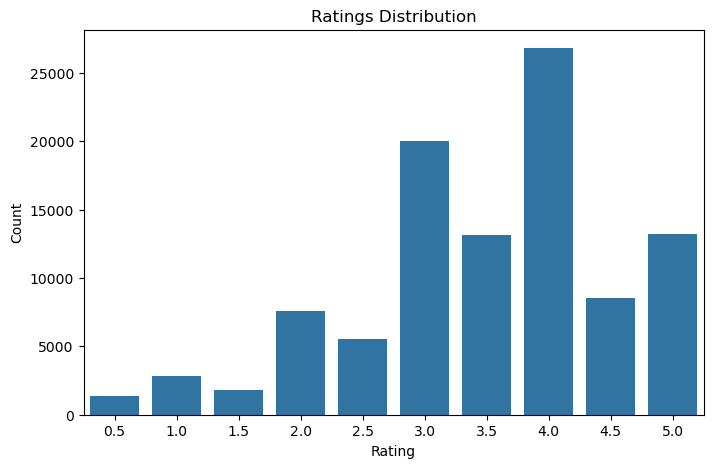

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(x=ratings['rating'])

plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

## 6. Most Active Users

In [20]:
user_activity = ratings.groupby('userId')['rating'].count()

user_activity.sort_values(ascending=False).head(10)

userId
414    2698
599    2478
474    2108
448    1864
274    1346
610    1302
68     1260
380    1218
606    1115
288    1055
Name: rating, dtype: int64

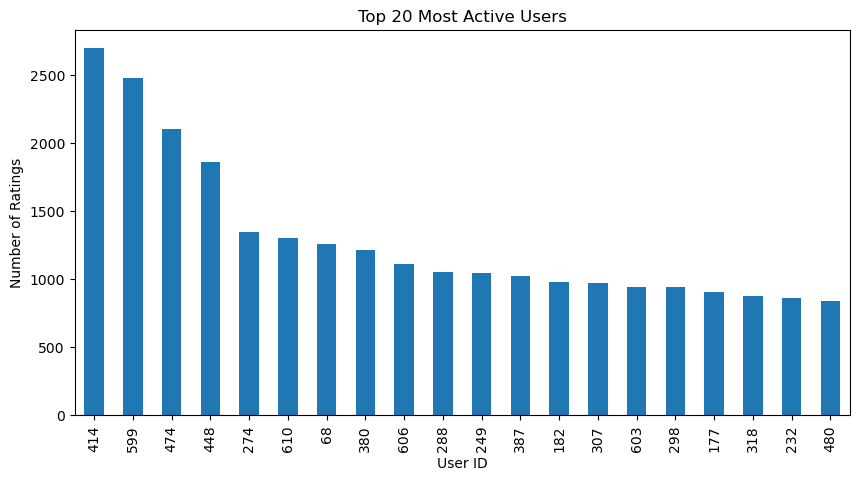

In [21]:
plt.figure(figsize=(10,5))

user_activity.sort_values(ascending=False).head(20).plot(kind='bar')

plt.title("Top 20 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Ratings")

plt.show()

## 7. Most Rated Movies

In [22]:
movie_rating_counts = ratings.groupby('movieId')['rating'].count()

top_movies = movie_rating_counts.sort_values(ascending=False).head(10)

top_movies

movieId
356     329
318     317
296     307
593     279
2571    278
260     251
480     238
110     237
589     224
527     220
Name: rating, dtype: int64

In [23]:
top_movies_df = pd.DataFrame(top_movies).reset_index()

top_movies_df = top_movies_df.merge(
    movies[['movieId', 'title']],
    on='movieId'
)

top_movies_df

,movieId,rating,title
0,356,329,Forrest Gump (1994)
1,318,317,"Shawshank Redemption, The (1994)"
2,296,307,Pulp Fiction (1994)
3,593,279,"Silence of the Lambs, The (1991)"
4,2571,278,"Matrix, The (1999)"
5,260,251,Star Wars: Episode IV - A New Hope (1977)
6,480,238,Jurassic Park (1993)
7,110,237,Braveheart (1995)
8,589,224,Terminator 2: Judgment Day (1991)
9,527,220,Schindler's List (1993)


## 8. Ratings Matrix Sparsity

In [24]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()

possible_ratings = n_users * n_movies
actual_ratings = len(ratings)

sparsity = (1 - (actual_ratings / possible_ratings)) * 100

print(f"Number of users: {n_users}")
print(f"Number of movies: {n_movies}")
print(f"Actual ratings: {actual_ratings}")
print(f"Sparsity: {sparsity:.2f}%")

Number of users: 610
Number of movies: 9724
Actual ratings: 100836
Sparsity: 98.30%


## 9. Initial Insights

# Initial Insights

- The MovieLens dataset contains 610 users and more than 9,700 movies.
- The ratings matrix is highly sparse (98.30%), which is a common challenge in recommender systems.
- A small number of users contribute a large portion of ratings, indicating user activity imbalance.
- Popular movies receive significantly more ratings than others, creating popularity bias.
- The dataset is suitable for collaborative filtering, group recommendation, and fairness-aware recommendation experiments.